# **Lab 7.1 Data Augmentation with PyTorch**

In [2]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader,Subset
from torch.nn import functional as F
import random
import cv2
import numpy as np
from skimage.util import random_noise
import matplotlib.pyplot as plt
import os
import math

Complete the `load_data()` function that loads the image using `ImageFolder()` with the specific `transforms.compose()` provided below.
`load_data()` will return DataLoader() and print the information about the Dataset.

`transforms.Compose()` :
- `transforms.Resize()`
- `transforms.ToTensor()`
- `transforms.Pad()`
- `transforms.RandomAffine(degrees=45, translate=(0.1, 0.1),scale=(0.8, 1.2), shear=45)`
- `transforms.CenterCrop()`

Resource : [`transforms.Compose()`](https://pytorch.org/vision/main/generated/torchvision.transforms.Compose.html#compose), [`torchvision.transforms v1`](<https://pytorch.org/vision/stable/transforms.html#v1-api-reference:~:text=custom)%20tv_tensor%20type.-,V1%20API%20Reference,-Geometry>), [`ImageFolder`](https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html), [`Dataloader`](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html#:~:text=Preparing%20your%20data%20for%20training%20with%20DataLoaders)

In [3]:
from collections import Counter
def load_data(path):
    ### START CODE HERE ###
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Pad(padding=224, padding_mode='reflect'),
        transforms.RandomAffine(degrees=45, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=45),
        transforms.CenterCrop((224, 224)),
        transforms.ToTensor(),
    ])

    dataset = ImageFolder(root=path, transform=transform)

    data_loader = DataLoader(dataset, batch_size=16, shuffle=True)
    
    return data_loader

    ### END CODE HERE ###

Use your load_data() function to load the dataset in the cell below. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

```
📃Train Dataset:
	Number of images in class battleship: 44
	Number of images in class patrol boat: 35
	Number of images in class submarine: 35
	Number of samples: 114
```


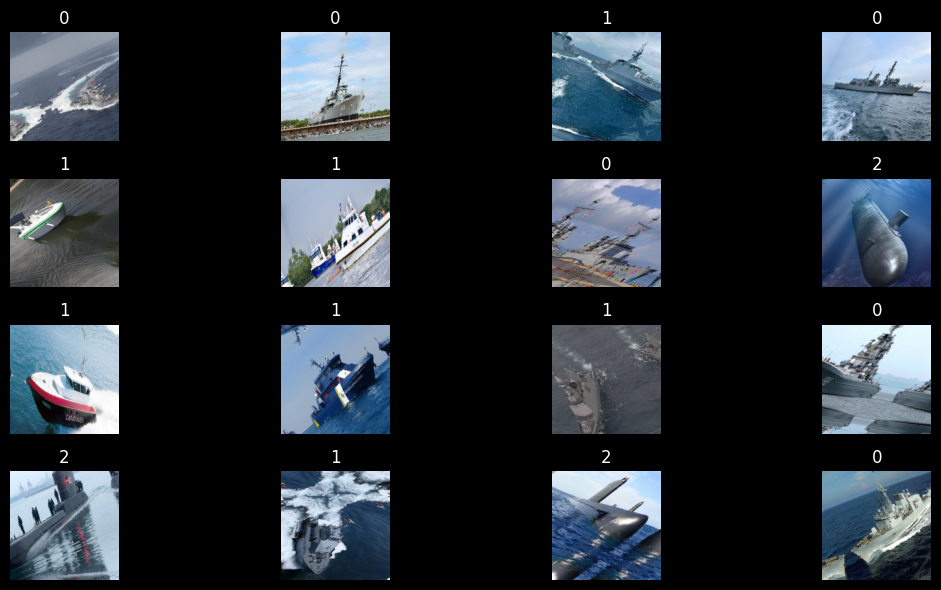

</details>

Number of images for class battleship: 44
Number of images for class patrol boat: 35
Number of images for class submarine: 35
Number of samples: 114


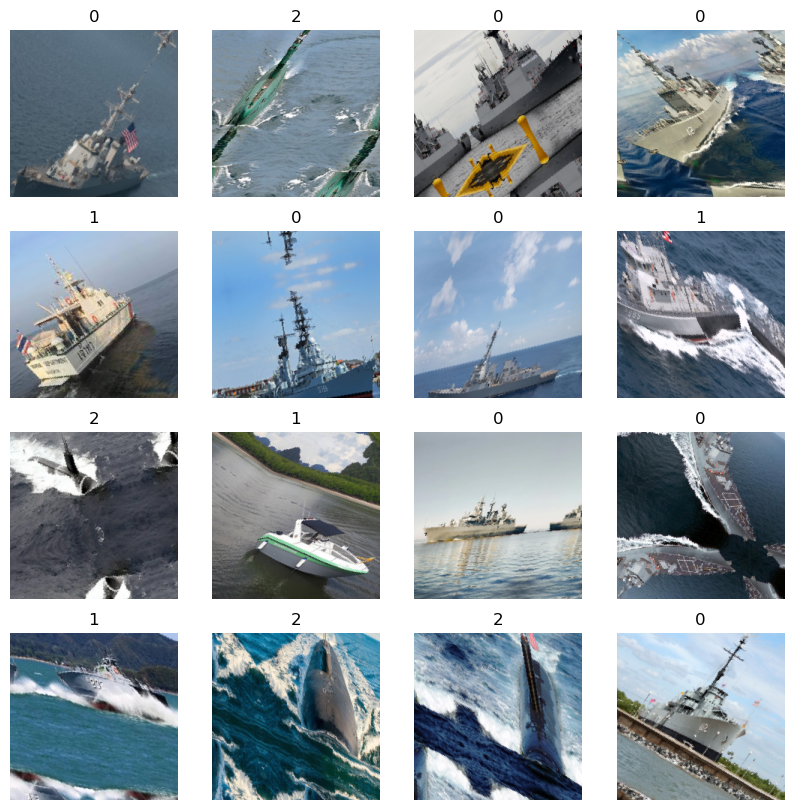

In [4]:
### START CODE HERE ###
data_loader = load_data('/home/crueang/Chaks/image_processing-2024/data/Ship/Train')
features, labels = next(iter(data_loader))
print(data_loader)

dataset = data_loader.dataset

idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
classes = [idx_to_class[label] for _, label in dataset]
classes = Counter(classes)
for c in classes:
    print(f'Number of images for class {c}: {classes[c]}')
print(f'Number of samples: {len(dataset)}')

fig, axs = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(features[i].permute(1, 2, 0))
    ax.set_title(labels[i].item())
    ax.axis('off')

### END CODE HERE ###

Now, let's create your own `CustomImageDataset` that performs the augmentation as in the previous section, but also includes the methods `add_gaussian_blur()` and `add_gaussian_noise()`. **<font color="red">DO NOT</font>** use `transforms.Compose()`.

Resource : [CustomImageDataset](https://pytorch.org/tutorials/beginner/data_loading_tutorial.html#:~:text=.show()-,Dataset%20class,-torch.utils.data)

In [6]:
### START CODE HERE ###
from math import floor, ceil
import torch
import torch.nn.functional as F
def resize(image, new_height, new_width, mode=None):
    if mode not in ['zero', 'bilinear', 'cubic']:
        raise ValueError(f'Invalid mode {mode}. Supported modes are zero, bilinear, cubic')
    
    if len(image.shape) == 3:
        old_height, old_width, channels = image.shape
    else:
        old_height, old_width = image.shape
        channels = 1
        image = np.expand_dims(image, axis=2)
    
    def P(x):
        return max(x, 0)

    def R(k):
        return (1/6)*(P(k+2)**3 - 4*P(k+1)**3 - 4*P(k-1)**3 + 6*P(k)**3)
        
    resized_image = np.zeros((new_height, new_width, channels), dtype=image.dtype)
    
    scale_x = old_width / new_width
    scale_y = old_height / new_height
    
    for row in range(new_height):
        for col in range(new_width):
            x = col * scale_x
            y = row * scale_y
            
            x0, y0 = floor(x), floor(y)
            x1, y1 = ceil(x), ceil(y)
            
            dx = x - x0
            dy = y - y0
            
            for channel in range(channels):
                def f(x, y):
                    if y >= old_height or x >= old_width:
                        return 0
                    return float(image[y, x, channel])
    
                if mode == 'zero' or mode is None:
                    pixel = image[y0, x0, channel]
                    
                if mode == 'bilinear':
                    pixel = f(x0, y0) + (f(x1, y0) - f(x0, y0))*dx\
                                    + (f(x0, y1) - f(x0, y0))*dy\
                                    + (f(x1, y1) + f(x0, y0) - f(x0, y1) - f(x1, y0))*dx*dy

                if mode == 'cubic':
                    pixel = 0
                    for m in range(-1, 3):
                        for n in range(-1, 3):
                            pixel += f(x0 + m, y0 + n)*R(m - dx)*R(dy - n)
                            
                                  
                resized_image[row, col, channel] = pixel
    if channels == 1:
        resized_image = np.squeeze(resized_image, axis = 2)
    
    return resized_image

def gaussian_blur(image, kernel_size, sd):
    # only accept odd kernel_size
    if kernel_size % 2 == 0:
        raise ValueError("Kernel size must be odd.")
    
    kernel = np.zeros((kernel_size, kernel_size), np.float32)
    half_ks = kernel_size // 2
    for y in range(-half_ks, half_ks + 1):
        for x in range(-half_ks, half_ks + 1):
            normal = 1 / (2 * np.pi * sd**2)
            exp_term = np.exp(-(x**2 + y**2) / (2 * sd**2))
            kernel[y + half_ks, x + half_ks] = normal * exp_term

    kernel /= np.sum(kernel)
    kernel = torch.tensor(kernel)
    kernel = kernel.view(1, 1, kernel_size, kernel_size)
    
    image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
    blurred_image = torch.zeros_like(image_tensor)
    
    for c in range(blurred_image.shape[1]):
        blurred_image[:, c, :, :] = F.conv2d(image_tensor[:, c, :, :], kernel, padding=half_ks)
        
    return blurred_image.squeeze().permute(1, 2, 0).numpy().astype(np.uint8)

def gaussian_noise(image, mean, sd, p):
    mask = np.random.rand(*image.shape) < p
    noise = np.random.normal(mean, sd, image.shape)
    noisy_image = image + noise
    noisy_image = np.where(mask, noisy_image, image)
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

def pad(image, pad_height, pad_width):
    h, w, c = image.shape
    ph = h + 2*pad_height
    pw = w + 2*pad_width
    
    padded_image = np.zeros((ph, pw, c), dtype=image.dtype)
    
    padded_image[pad_height:pad_height + h, pad_width:pad_width + w] = image
    
    padded_image[:pad_height, pad_width:-pad_width] = image[pad_height::-1, :]
    padded_image[-pad_height:, pad_width:-pad_width] = image[-1:-pad_height-1:-1, :]
    
    padded_image[pad_height:-pad_height, :pad_width] = image[:, pad_width::-1]
    padded_image[pad_height:-pad_height, -pad_width:] = image[:, -1:-pad_width-1:-1]
    
    padded_image[:pad_height, :pad_width] = image[pad_height::-1, pad_width::-1]
    padded_image[:pad_height, -pad_width:] = image[pad_height::-1, -1:-pad_width-1:-1]
    padded_image[-pad_height:, :pad_width] = image[-1:-pad_height-1:-1, pad_width::-1]
    padded_image[-pad_height:, -pad_width:] = image[-1:-pad_height-1:-1, -1:-pad_width-1:-1]
    
    return padded_image

def translateMatrix(image, value=(0, 0)):
    original_height, original_width, channels = image.shape

    translate_image = np.zeros((original_height, original_width, channels), dtype=image.dtype)

    for i in range(original_height):
        for j in range(original_width):
            
            orig_y = i - value[1]
            orig_x = j - value[0]

            if 0 <= round(orig_y) < original_height and 0 <= round(orig_x) < original_width:
                translate_image[i, j] = image[round(orig_y), round(orig_x)]
    return translate_image

def scaleMatrix(image, scale_factors=1):
    original_height, original_width, channels = image.shape

    scaled_image = np.zeros((original_height, original_width, channels), dtype=image.dtype)
    
    center_x = original_width/2
    center_y = original_height/2
    
    scale_factors = 1/scale_factors
    
    scale_matrix = np.array([
        [scale_factors, 0, -center_x*(scale_factors - 1)],
        [0, scale_factors, -center_y*(scale_factors - 1)],
        [0, 0, 1]
    ])

    for i in range(original_height):
        for j in range(original_width):

            orig_x, orig_y, _ = np.dot(scale_matrix, [j, i, 1])

            if 0 <= round(orig_y) < original_height and 0 <= round(orig_x) < original_width:
                scaled_image[i, j] = image[round(orig_y), round(orig_x)]

    return scaled_image

def shearMatrix(image, shear_factors=(1, 1)):
    original_height, original_width, channels = image.shape

    sheared_image = np.zeros((original_height, original_width, channels), dtype=image.dtype)
    
    shx, shy = shear_factors[0], shear_factors[1]
    
    det = abs(1 - shx*shy)
    if det == 0:
        raise ValueError('determinant is zero')
    
    shear_matrix = (1/det) * np.array([
        [1, shx, -shx*original_height/2],
        [shy, 1, -shy*original_width/2],
        [0, 0, 1]
    ])

    for i in range(original_height):
        for j in range(original_width):

            x, y, _ = np.dot(shear_matrix, [j, i, 1])

            if 0 <= round(y) < original_height and 0 <= round(x) < original_width:
                sheared_image[i, j] = image[round(y), round(x)]

    return sheared_image

def rotationMatrix(image, degree=0):
    original_height, original_width, channels = image.shape
    theta = math.radians(degree)

    rotated_image = np.zeros((original_height, original_width, channels), dtype=image.dtype)
    
    center_x = original_width / 2
    center_y = original_height / 2
    
    rotation_matrix = np.array([
        [np.cos(theta), -np.sin(theta), center_x * (1 - np.cos(theta)) + center_y * np.sin(theta)],
        [np.sin(theta), np.cos(theta), center_y * (1 - np.cos(theta)) - center_x * np.sin(theta)],
        [0, 0, 1]
    ])

    for i in range(original_height):
        for j in range(original_width):
            x, y, _ = np.dot(rotation_matrix, [j, i, 1])

            if 0 <= round(y) < original_height and 0 <= round(x) < original_width:
                rotated_image[i, j] = image[round(y), round(x)]

    return rotated_image

def center_crop(image, crop_h, crop_w):
    h, w = image.shape[:2]
    h, w = h//2, w//2
    crop_h = crop_h // 2
    crop_w = crop_w // 2
    
    return image[h-crop_h:h+crop_h, w-crop_w:w+crop_w,:]

def random_affine(image, degrees=0, translate=(0, 0), scale=(1, 1), shear=(0, 0)):
    angle = random.uniform(-degrees, degrees)
    
    max_dx = int(translate[0] * image.shape[1])
    max_dy = int(translate[1] * image.shape[0])
    translations = (random.uniform(-max_dx, max_dx), random.uniform(-max_dy, max_dy))


    scale_factor = random.uniform(scale[0], scale[1])


    shear_x = random.uniform(-shear[0], shear[0])
    shear_y = random.uniform(-shear[1], shear[1])

    image = translateMatrix(image, translations)
    image = scaleMatrix(image, scale_factor)
    image = shearMatrix(image, (shear_x, shear_y))
    image = rotationMatrix(image, angle)
    return image

class CustomImageDataset(Dataset):
    def __init__(self, image_paths=None):
        self.i = 0
        self.dataset = ImageFolder(root=image_paths, transform = self.apply_augmentation)
        self.class_to_idx = self.dataset.class_to_idx

    def apply_augmentation(self, image):
        image = np.array(image)
        image = resize(image,224, 224, mode='zero')
        kernel_size = random.randrange(3, 12, 2)
        blur_image = gaussian_blur(image,kernel_size,1)
        image = gaussian_noise(blur_image, np.random.uniform(-20, 20), 1, 0.5)
        image = pad(image,224,224)
        image = random_affine(image,degrees=45, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=(0.25,0))
        image = center_crop(image,224,224)
        image = transforms.ToTensor()(image)
        # image = Image.fromarray(np.uint8(image))
        return image

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return image, label
    
### END CODE HERE ###

Use your `CustomImageDataset()` function. Then, display the image from the first batch.

<details>
<summary>
<font size="3" color="orange">
<b>Expected output</b>
</font>
</summary>

- The output should resemble this, but not be identical

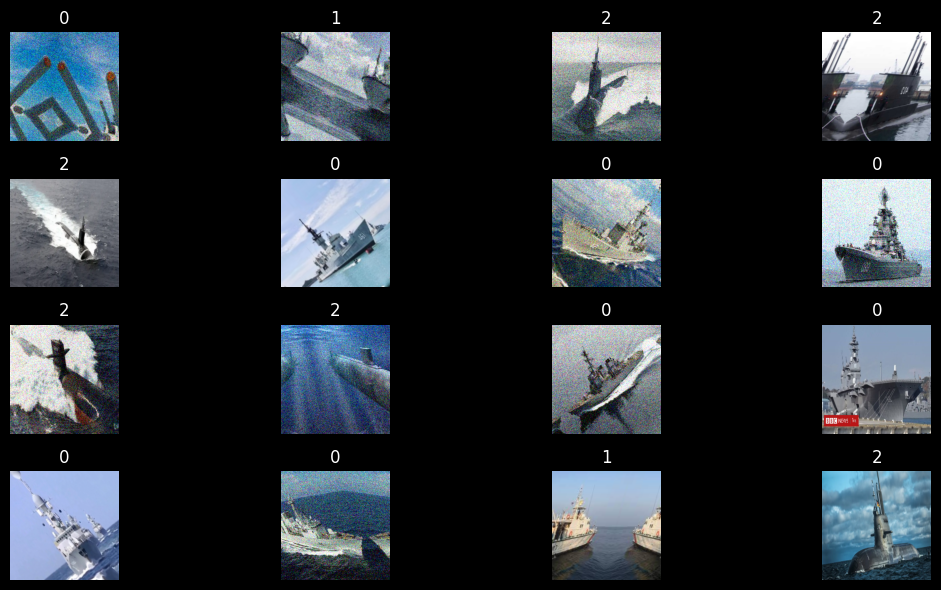

</details>

Number of images for class battleship: 5
Number of images for class patrol boat: 5
Number of images for class submarine: 6
Number of samples: 16


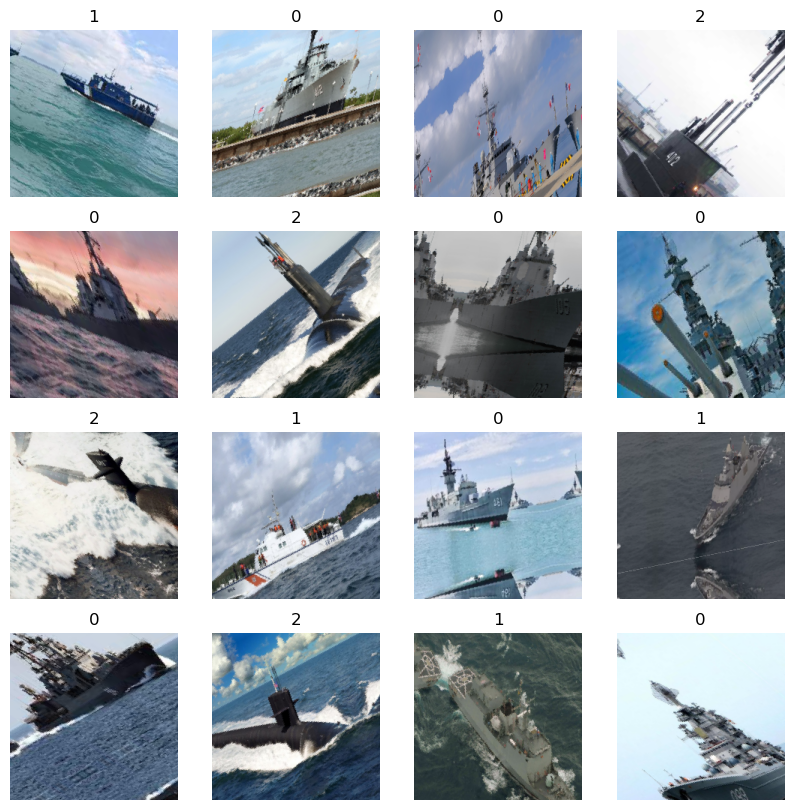

In [8]:
### START CODE HERE ###
import numpy as np
from math import floor, ceil
import matplotlib.pyplot as plt
import math
import random
dataset = CustomImageDataset('/home/crueang/Chaks/image_processing-2024/data/reduce_ship')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
features, labels = next(iter(data_loader))
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
classes = [idx_to_class[label] for _, label in dataset]
classes = Counter(classes)
for c in classes:
    print(f'Number of images for class {c}: {classes[c]}')
print(f'Number of samples: {len(dataset)}')

fig, axs = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(features[i].permute(1, 2, 0))
    ax.set_title(labels[i].item())
    ax.axis('off')
### END CODE HERE ###

---
# Questions
1. Discuss effects and benefits of fill_mode or padding_mode.
<br> effects คือการเติมขอบเข้าไปในรูป มีหลาย mode เช่น การเติมสีที่เป็นค่าคงที่, reflect รูปปัจจุบันออกไปด้านข้าง, wrap ทำซ้ำภาพนำมาต่อกันไปเรื่อย ๆ, nearest ใช้ค่าสีที่อยู่ใกล้ที่สุด
    - ป้องกันการสูญเสียข้อมูลจากการ crop ภาพเกินขอบ
    - ทำให้โมเดลเรียนรู้ object ที่อยู่ใกล้ขอบได้ดีขึ้น
    - เพิ่มความหลากหลายให้กับข้อมูล
2. What would be amount of augmentation should be so that it would not effect the training performance? 
<br>=ต้องเลือกให้เหมาะสมกับ dataset ที่ใช้ เช่น dataset เลขไทยก็ไม่ควรหมุนเกิน 45 องศา เพราะจะทำให้เลข ๗ กลายเป็นเลข ๙ ได้
3. How can we create Salt-and-Pepper Noise, which is the type that greatly affect the image quality? =
<br>=สร้าง mask ที่สุ่ม probability ว่า pixel นั้นจะทำการ add noise หรือไม่ จากนั้นทำการสุ่มเลข 0 หรือ 1 ใส่ array_noise แล้วใช้ np.where เลือกช่องที่ mask มีค่าเกิน prob ให้ใช้ค่าจาก array_noise แทน ช่องอื่นจะใช้ค่าจาก image ตั้งต้น
4. What would be transform parameter to simulate camera lense effect? 
<br>camera zoom = scale, camera blur = gaussian blur
<br>camera distortion = 
$$
x_{distorted} = x \cdot (1 + k_1 r^2 + k_2 r^4 + k_3 r^6)
$$
$$
y_{distorted} = y \cdot (1 + k_1 r^2 + k_2 r^4 + k_3 r^6)
$$